This is our first attempt at trying out tensorflow and Keras API... We'll build some Multi Layer Perceptons (MLPs).. Let's see how it goes

# Sequential API 

### Image Classifer

We'll be exploring the **Fashion MNIST** Dataset... Similar to the classic MNIST (70,000 images esach of 28 xx 28 pixels with 10 classes) but fashion items instead of handwritten digits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf

fashion_mnist= tf.keras.datasets.fashion_mnist.load_data() 
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [3]:
X_train_full.shape

(60000, 28, 28)

In [4]:
X_train, y_train= X_train_full[ :-5000], y_train_full[ :-5000]
X_valid, y_valid= X_train_full[-5000: ], y_train_full[-5000: ]

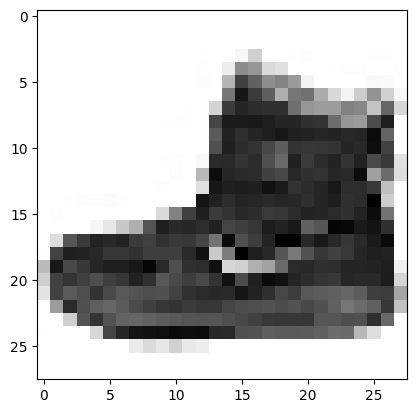

In [5]:
import matplotlib.pyplot as plt
## Let's checkout the first image
plt.imshow(X_train[0], cmap= "Greys")

In [6]:
X_train.shape

(55000, 28, 28)

Currently, the pixel intensitites are ranged from 0-255.. let's take that down to 0-1 range

In [7]:
X_train, X_valid, X_test= X_train/ 255, X_valid/255, X_test/ 255

In [8]:
class_names= ["T_shirt", "Trousers", "Pullover", "Dress", "Coat", 
             "SandaL", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
class_names[y_train[0]]

'Ankle boot'

In [10]:
indices= np.random.choice(55000, 40, replace=False)   # 0–54999

In [11]:
indices

array([13833,  2957,  4994, 28315, 22564, 19950, 46113, 49560, 19341,
       41714, 34776, 50255,   788,  2628, 49098,  4905, 51801, 50789,
       51370,  8852, 21432, 36000, 47338, 21316,  8710, 31259, 46551,
       16055, 16431,  3080,  1356, 50022, 29947, 34524, 16704, 43442,
       52528, 54284, 25911, 53081])

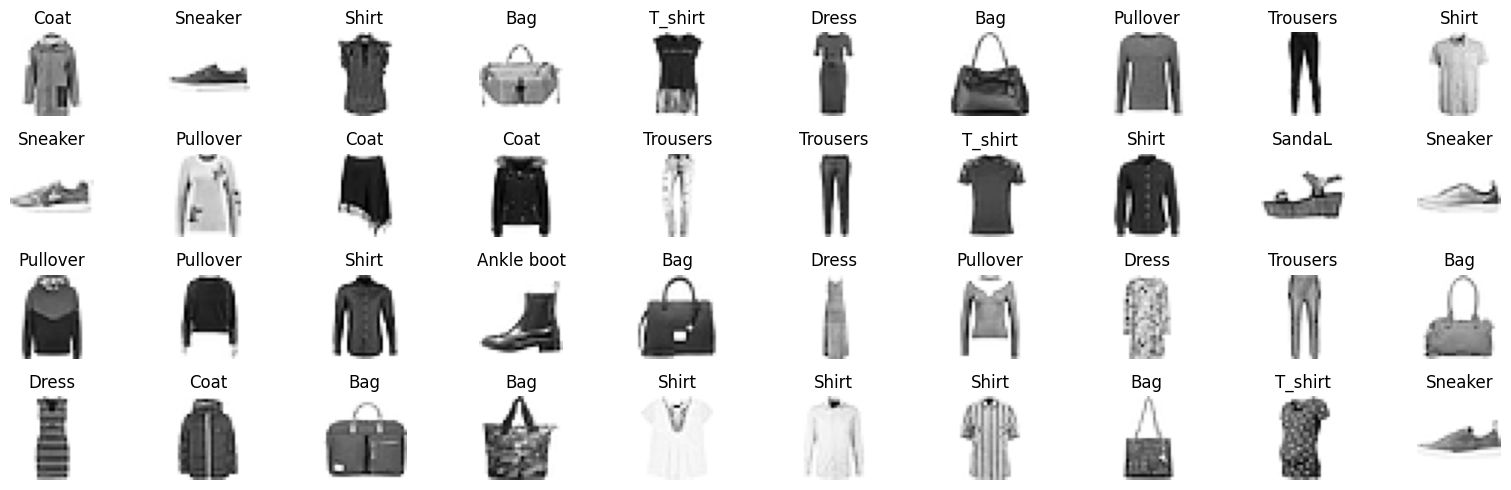

In [12]:
fig, axes= plt.subplots(4, 10, figsize= (16,5))

for i, ax in zip(indices, axes.ravel()): 
    ax.imshow(X_train[i], cmap= "Greys")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")


plt.tight_layout()

### Modelling

In [13]:
model= tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= [28,28]), #Flattten the 28 x 28 matrix into a 784 1d matrix
    tf.keras.layers.Dense(300, activation= "relu"), 
    tf.keras.layers.Dense(100, activation= "relu"), 
    tf.keras.layers.Dense(10, activation= "softmax")
])

C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

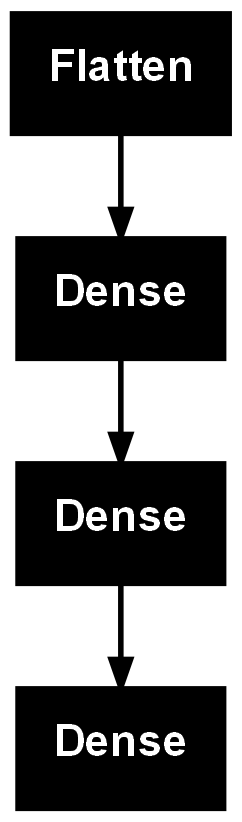

In [15]:
tf.keras.utils.plot_model(model)

In [16]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [17]:
hidden1= model.layers[1]

In [18]:
weights, biases= hidden1.get_weights()

In [19]:
weights

array([[-0.04745773,  0.03489123, -0.07120686, ...,  0.05158585,
         0.0704755 ,  0.05979089],
       [ 0.00976975,  0.03055637, -0.03446956, ...,  0.01177428,
        -0.03750359, -0.05588659],
       [-0.00556376,  0.05894199,  0.04068748, ...,  0.0401345 ,
         0.0433254 ,  0.010045  ],
       ...,
       [ 0.00828867, -0.05522273, -0.07031778, ...,  0.04122013,
        -0.04182573, -0.00846167],
       [ 0.05156848,  0.02819806, -0.01169965, ...,  0.05312417,
         0.019567  ,  0.04156943],
       [-0.03262431,  0.02366202, -0.05774177, ..., -0.0210098 ,
        -0.06353064, -0.02587533]], dtype=float32)

In [20]:
weights.shape

(784, 300)

Weights are initialised randomly *(not to 0)* in order to break the symmetry

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [22]:
biases.shape

(300,)

In [23]:
model.compile(loss= "sparse_categorical_crossentropy", 
              optimizer= "sgd", 
              metrics = ["accuracy"])

In [24]:
history = model.fit(X_train, y_train, epochs= 40, 
                   validation_data= (X_valid, y_valid))

Epoch 1/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6909 - loss: 0.9894 - val_accuracy: 0.8196 - val_loss: 0.5234
Epoch 2/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8252 - loss: 0.4994 - val_accuracy: 0.8376 - val_loss: 0.4618
Epoch 3/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8436 - loss: 0.4474 - val_accuracy: 0.8534 - val_loss: 0.4117
Epoch 4/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8568 - loss: 0.4115 - val_accuracy: 0.8536 - val_loss: 0.4080
Epoch 5/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8621 - loss: 0.3922 - val_accuracy: 0.8616 - val_loss: 0.3905
Epoch 6/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8674 - loss: 0.3753 - val_accuracy: 0.8564 - val_loss: 0.3897
Epoch 7/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8726 - loss: 0.3634 - val_accuracy: 0.8700 - val_loss: 0.3691
Epoch 8/40
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8740 - loss: 0.3517 - 

In [25]:
history.history

{'accuracy': [0.7673818469047546,
  0.831636369228363,
  0.8462908864021301,
  0.8558545708656311,
  0.8617454767227173,
  0.8679999709129333,
  0.8724545240402222,
  0.8746545314788818,
  0.879909098148346,
  0.8829454779624939,
  0.8858727216720581,
  0.8881272673606873,
  0.8903999924659729,
  0.8928181529045105,
  0.8953272700309753,
  0.8976181745529175,
  0.8989454507827759,
  0.9010545611381531,
  0.9031636118888855,
  0.9038181900978088,
  0.9067272543907166,
  0.9085817933082581,
  0.9100000262260437,
  0.911618173122406,
  0.913527250289917,
  0.9146000146865845,
  0.9156545400619507,
  0.9174000024795532,
  0.9197818040847778,
  0.9201454520225525,
  0.92207270860672,
  0.9229636192321777,
  0.9249454736709595,
  0.9255454540252686,
  0.9269090890884399,
  0.9283636212348938,
  0.9304909110069275,
  0.9312182068824768,
  0.9319090843200684,
  0.9331636428833008],
 'loss': [0.7123308181762695,
  0.4840175211429596,
  0.43965381383895874,
  0.4126933515071869,
  0.393102347850

<Axes: xlabel='Epoch'>

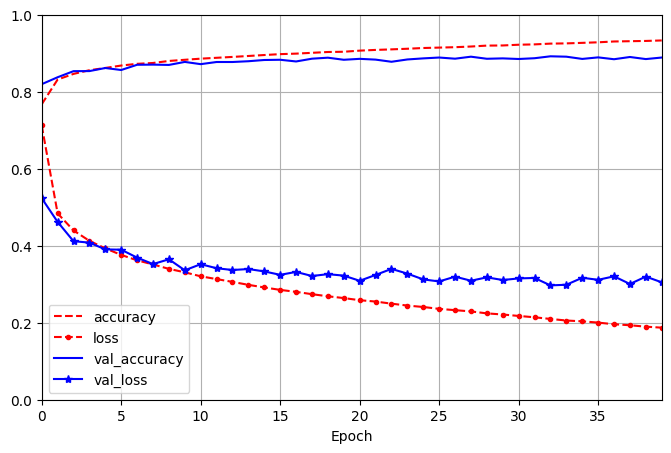

In [26]:
pd.DataFrame(history.history).plot(
    figsize= (8,5), xlim= [0,39], ylim= [0,1], grid = True, xlabel = "Epoch", 
    style= ["r--", "r--.", "b-", "b-*"]
)

In [27]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8918 - loss: 0.3258


[0.3234386146068573, 0.8920000195503235]

### MLP Regression

Let's now have a look at a regression model using MLPs

In [28]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing= fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state= 42
)
X_train, X_valid, y_train, y_valid= train_test_split(
    X_train_full, y_train_full, random_state= 42
)


In [29]:
X_train.shape

(11610, 8)

In [30]:
X_train.shape[1: ]

(8,)

In [31]:
tf.random.set_seed(42) 
norm_layer= tf.keras.layers.Normalization(input_shape= X_train.shape[1: ]) 

model = tf.keras.Sequential([
    norm_layer, 
    tf.keras.layers.Dense(50, activation= "relu"), 
    tf.keras.layers.Dense(50, activation= "relu"), 
    tf.keras.layers.Dense(50, activation= "relu"), 
    tf.keras.layers.Dense(1)
])

optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model.compile(loss= "mse", optimizer= optimizer, metrics= ["RootMeanSquaredError"])

norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs= 20, 
                    validation_data= (X_valid, y_valid))

mse_test, rmse_test= model.evaluate(X_test, y_test)

Epoch 1/20


C:\Users\Taif Al Ghazali\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - RootMeanSquaredError: 1.2006 - loss: 1.5602 - val_RootMeanSquaredError: 0.7939 - val_loss: 0.6303
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6280 - loss: 0.3949 - val_RootMeanSquaredError: 0.6642 - val_loss: 0.4412
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6069 - loss: 0.3685 - val_RootMeanSquaredError: 1.0426 - val_loss: 1.0871
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5926 - loss: 0.3514 - val_RootMeanSquaredError: 1.2054 - val_loss: 1.4529
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5837 - loss: 0.3408 - val_RootMeanSquaredError: 1.2429 - val_loss: 1.5447
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5743 - loss: 0.3299 - val_RootMeanSquaredError: 1.0401 - val_loss: 1.0818
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5642 - loss: 0.3184 -

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ normalization (Normalization)        │ (None, 8)                   │              17 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 50)                  │             450 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,822 (65.72 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 11,204 (43.77 KB)

# Functional API

### A *wide* and *deep* neural network

In [33]:
normalization_layer= tf.keras.layers.Normalization() 
hidden_layer1 = tf.keras.layers.Dense(30, activation = "relu")
hidden_layer2= tf.keras.layers.Dense(30, activation= "relu")
concat_layer= tf.keras.layers.Concatenate()
output_layer= tf.keras.layers.Dense(1)


input_= tf.keras.layers.Input(shape= X_train.shape[1: ])
normalized= normalization_layer(input_)
hidden1= hidden_layer1(normalized)
hidden2= hidden_layer2(hidden1)
concat= concat_layer([normalized, hidden2])
output= output_layer(concat)

model= tf.keras.Model(inputs= [input_], outputs= [output])

optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model.compile(loss= "mse", 
              optimizer= optimizer, 
              metrics= ["RootMeanSquaredError"])

normalization_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs= 20, 
                    validation_data= (X_valid, y_valid))

mse_test, rmse_test= model.evaluate(X_test, y_test)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.4108 - loss: 2.1076 - val_RootMeanSquaredError: 1.0614 - val_loss: 1.1266
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6978 - loss: 0.4881 - val_RootMeanSquaredError: 0.6313 - val_loss: 0.3985
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6447 - loss: 0.4161 - val_RootMeanSquaredError: 0.7212 - val_loss: 0.5202
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6226 - loss: 0.3879 - val_RootMeanSquaredError: 0.8261 - val_loss: 0.6824
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6090 - loss: 0.3711 - val_RootMeanSquaredError: 0.9795 - val_loss: 0.9594
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6004 - loss: 0.3607 - val_RootMeanSquaredError: 1.2912 - val_loss: 1.6672
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.5957 - los

Hmm. same as above

This is called a functional API btw because have a look at the way we are clalling the different layers as functions of their previous ones

We'll try **bootstrapping** feautres now

In [34]:
input_wide= tf.keras.layers.Input(shape= [5])
input_deep= tf.keras.layers.Input(shape= [6])
norm_layer_wide= tf.keras.layers.Normalization()
norm_layer_deep= tf.keras.layers.Normalization()

norm_wide= norm_layer_wide(input_wide)
norm_deep= norm_layer_deep(input_deep)
hidden1= tf.keras.layers.Dense(30, activation= "relu")(norm_deep)
hidden2= tf.keras.layers.Dense(30, activation= "relu")(hidden1)

concat= tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

model = tf.keras.Model(inputs= [input_wide, input_deep], outputs= [output])

In [35]:

optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model.compile(loss= "mse", 
              optimizer= optimizer, 
              metrics= ["RootMeanSquaredError"])

#Bootstrapped Features
X_train_wide, X_train_deep= X_train[:, :5], X_train[:,2: ]
X_valid_wide, X_valid_deep= X_valid[:, :5], X_valid[:,2: ]
X_test_wide, X_test_deep = X_test[:, :5], X_test[:, 2: ]


norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)

history = model.fit((X_train_wide, X_train_deep), y_train, epochs= 20, 
                    validation_data= ((X_valid_wide, X_valid_deep), y_valid))

mse_test, rmse_test= model.evaluate((X_test_wide, X_test_deep), y_test)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - RootMeanSquaredError: 1.6649 - loss: 2.8990 - val_RootMeanSquaredError: 0.8747 - val_loss: 0.7652
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7935 - loss: 0.6305 - val_RootMeanSquaredError: 0.7843 - val_loss: 0.6151
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6983 - loss: 0.4878 - val_RootMeanSquaredError: 0.6411 - val_loss: 0.4110
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6595 - loss: 0.4351 - val_RootMeanSquaredError: 0.7003 - val_loss: 0.4904
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6375 - loss: 0.4065 - val_RootMeanSquaredError: 0.7124 - val_loss: 0.5075
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6250 - loss: 0.3907 - val_RootMeanSquaredError: 0.8884 - val_loss: 0.7893
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6143 - los

Honestly, model is'nt improving by these methods

In [36]:
## Adding extra output layers

In [37]:
input_wide= tf.keras.layers.Input(shape= [5])
input_deep= tf.keras.layers.Input(shape= [6])
norm_layer_wide= tf.keras.layers.Normalization()
norm_layer_deep= tf.keras.layers.Normalization()

norm_wide= norm_layer_wide(input_wide)
norm_deep= norm_layer_deep(input_deep)
hidden1= tf.keras.layers.Dense(30, activation= "relu")(norm_deep)
hidden2= tf.keras.layers.Dense(30, activation= "relu")(hidden1)

concat= tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)
aux_output= tf.keras.layers.Dense(1)(hidden2)


model = tf.keras.Model(inputs= [input_wide, input_deep], outputs= [output, aux_output])

We care much more about the main output than the auxillary output, which is used mainly for regularization.. hence, use higher weightage for main output loss

In [38]:
optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model.compile(loss= ("mse", "mse"), loss_weights=(0.9, 0.1), optimizer= optimizer, metrics= ["RootMeanSquaredError", "RootMeanSquaredError" ] )

In [39]:
norm_layer_wide.adapt(X_train_wide)
norm_layer_deep.adapt(X_train_deep)
history = model.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs = 20, 
    validation_data= ((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - dense_15_RootMeanSquaredError: 1.4607 - dense_15_loss: 2.2206 - dense_16_RootMeanSquaredError: 1.8640 - dense_16_loss: 3.5938 - loss: 2.3579 - val_dense_15_RootMeanSquaredError: 0.7378 - val_dense_15_loss: 0.5443 - val_dense_16_RootMeanSquaredError: 1.5977 - val_dense_16_loss: 2.5517 - val_loss: 0.7452
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_15_RootMeanSquaredError: 0.7318 - dense_15_loss: 0.5364 - dense_16_RootMeanSquaredError: 0.9502 - dense_16_loss: 0.9042 - loss: 0.5732 - val_dense_15_RootMeanSquaredError: 0.6453 - val_dense_15_loss: 0.4164 - val_dense_16_RootMeanSquaredError: 1.0083 - val_dense_16_loss: 1.0164 - val_loss: 0.4765
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_15_RootMeanSquaredError: 0.6695 - dense_15_loss: 0.4486 - dense_16_RootMeanSquaredError: 0.8161 - dense_16_loss: 0.6664 - loss: 0.4704 - val_dense_15_RootMeanSquaredError: 0.6862 - val_dense_15_loss: 0.4708 - val_dense_16_Ro

In [40]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 6)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_5               │ (None, 6)                 │              13 │ input_layer_6[0][0]        │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 5)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_13 (Dense)              │ (None, 30)                │             210 │ normalization_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization_4               │ (None, 5)                 │              11 │ input_layer_5[0][0]        │
│ (Normalization)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 30)                │             930 │ dense_13[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 35)                │               0 │ normalization_4[0][0],     │
│                               │                           │                 │ dense_14[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_15 (Dense)              │ (None, 1)                 │              36 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_16 (Dense)              │ (None, 1)                 │              31 │ dense_14[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [41]:
eval_results= model.evaluate((X_test_wide, X_test_deep), (y_test, y_test))
weighted_sum_of_losses, main_loss, aux_loss, main_rmse, aux_rmse= eval_results

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - dense_15_RootMeanSquaredError: 0.5765 - dense_15_loss: 0.3325 - dense_16_RootMeanSquaredError: 0.6335 - dense_16_loss: 0.4014 - loss: 0.3394


# Subclassing API

One of the biggest issues with Functional and Sequential API is that they're static.. you give an input shape that does'nt match the necessary format, nothing works. If you want your model to be dynamic, here's a look at Subclassing API

Unlike the other two, which are **declarative**.. (just declare what you want).. Subclassing API is an **imperative** style of defining your model (give a step by step procedure)

Let's see something like this for our functional API

In [42]:
class WideAndDeepModel(tf.keras.Model): 
    def __init__(self, units= 30, activation= "relu", **kwargs): 
        super().__init__(**kwargs) ## needed to support naming the model
        self.norm_layer_wide= tf.keras.layers.Normalization()
        self.norm_layer_deep= tf.keras.layers.Normalization()
        self.hidden1= tf.keras.layers.Dense(units, activation= activation)
        self.hidden2= tf.keras.layers.Dense(units, activation= activation)
        self.main_output= tf.keras.layers.Dense(1)
        self.aux_output= tf.keras.layers.Dense(1)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide= self.norm_layer_wide(input_wide)
        norm_deep= self.norm_layer_deep(input_deep)
        hidden1= self.hidden1(norm_deep)
        hidden2= self.hidden2(hidden1)
        concat= tf.keras.layers.concatenate([norm_wide, hidden2])
        output= self.main_output(concat)
        aux_output= self.aux_output(hidden2)
        return output, aux_output

model= WideAndDeepModel(30, activation= "relu", name= "relu_model")

In [43]:
model_relu= WideAndDeepModel(30, activation= "relu", name= "relu_model")

optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model_relu.compile(loss= ("mse", "mse"), loss_weights=(0.9, 0.1), optimizer= optimizer, metrics= ["RootMeanSquaredError", "RootMeanSquaredError" ] )

model_relu.norm_layer_wide.adapt(X_train_wide)
model_relu.norm_layer_deep.adapt(X_train_deep)

history = model_relu.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs = 20, 
    validation_data= ((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

rmse_test= model_relu.evaluate((X_test_wide, X_test_deep), (y_test, y_test))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 1.5644 - RootMeanSquaredError_1: 1.6092 - loss: 2.5498 - mse_loss: 2.6410 - val_RootMeanSquaredError: 2.0011 - val_RootMeanSquaredError_1: 0.9336 - val_loss: 3.6910 - val_mse_loss: 0.8715
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7606 - RootMeanSquaredError_1: 0.8718 - loss: 0.5970 - mse_loss: 0.7610 - val_RootMeanSquaredError: 0.9140 - val_RootMeanSquaredError_1: 0.9658 - val_loss: 0.8452 - val_mse_loss: 0.9324
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6864 - RootMeanSquaredError_1: 0.7756 - loss: 0.4843 - mse_loss: 0.6018 - val_RootMeanSquaredError: 0.7158 - val_RootMeanSquaredError_1: 0.8127 - val_loss: 0.5271 - val_mse_loss: 0.6604
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.6524 - RootMeanSquaredError_1: 0.7388 - loss: 0.4378 - mse_loss: 0.5459 - val_RootMeanSquaredError: 0.6255 - val_RootMeanSquaredEr

In [44]:
model_tanh= WideAndDeepModel(30, activation= "tanh", name= "tanh_model")

optimizer= tf.keras.optimizers.Adam(learning_rate= 1e-3)
model_tanh.compile(loss= ("mse", "mse"), loss_weights=(0.9, 0.1), optimizer= optimizer, metrics= ["RootMeanSquaredError", "RootMeanSquaredError" ] )

model_tanh.norm_layer_wide.adapt(X_train_wide)
model_tanh.norm_layer_deep.adapt(X_train_deep)

history = model_tanh.fit(
    (X_train_wide, X_train_deep), (y_train, y_train), epochs = 20, 
    validation_data= ((X_valid_wide, X_valid_deep), (y_valid, y_valid))
)

rmse_test= model_tanh.evaluate((X_test_wide, X_test_deep), (y_test, y_test))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - RootMeanSquaredError: 1.6760 - RootMeanSquaredError_1: 1.8430 - loss: 3.0005 - mse_loss: 3.5219 - val_RootMeanSquaredError: 0.8201 - val_RootMeanSquaredError_1: 0.8488 - val_loss: 0.6774 - val_mse_loss: 0.7204
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.8773 - RootMeanSquaredError_1: 0.8765 - loss: 0.7711 - mse_loss: 0.7685 - val_RootMeanSquaredError: 0.7463 - val_RootMeanSquaredError_1: 0.8340 - val_loss: 0.5709 - val_mse_loss: 0.6955
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.8037 - RootMeanSquaredError_1: 0.8609 - loss: 0.6566 - mse_loss: 0.7413 - val_RootMeanSquaredError: 0.6981 - val_RootMeanSquaredError_1: 0.8198 - val_loss: 0.5058 - val_mse_loss: 0.6719
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - RootMeanSquaredError: 0.7528 - RootMeanSquaredError_1: 0.8440 - loss: 0.5820 - mse_loss: 0.7125 - val_RootMeanSquaredError: 0.6675 - val_RootMeanSquaredEr

Pretty similar.. huh

### Fine Tuning HyperParamaters

In [75]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [76]:
X_train, y_train= X_train_full[ :-5000], y_train_full[ :-5000]
X_valid, y_valid= X_train_full[-5000: ], y_train_full[-5000: ]

In [77]:
X_train_full

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [78]:
y_train

array([9, 0, 0, ..., 9, 0, 2], dtype=uint8)

In [79]:
def build_model(hp):
    n_hidden= hp.Int("n_hidden", min_value= 0, max_value= 8, default= 2)
    n_neurons= hp.Int("n_neurons", min_value= 16, max_value= 256)
    learning_rate= hp.Float("learning_rate", min_value= 1e-4, max_value= 1e-2, sampling= "log")
    optimizer= hp.Choice("optimizer", values= ["sgd", "adam"])
    if optimizer == "sgd": 
        optimizer= tf.keras.optimizers.SGD(learning_rate= learning_rate)
    else: 
        optimizer= tf.keras.optimizers.Adam(learning_rate= learning_rate)

    model= tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation = "relu"))
    model.add(tf.keras.layers.Dense(10, activation = "softmax"))
    model.compile(loss= "sparse_categorical_crossentropy", optimizer= optimizer, 
                 metrics= ["accuracy"])
    return model

In [80]:
import keras_tuner as kt

random_search_tuner= kt.RandomSearch(
    build_model, objective= "val_accuracy", max_trials= 5, overwrite= True, 
    directory= "fashion_mnist", project_name= "rnd_search", seed= 42
)

random_search_tuner.search(X_train, y_train, epochs= 10, validation_data= (X_valid, y_valid))

Trial 5 Complete [00h 00m 42s]
val_accuracy: 0.8338000178337097

Best val_accuracy So Far: 0.8489999771118164
Total elapsed time: 00h 03m 41s


In [81]:
top3 = random_search_tuner.get_best_models(num_models=3)

best_model = top3[0]

In [82]:
best_model

<Sequential name=sequential, built=True>

In [83]:
top3_params= random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values

{'n_hidden': 8,
 'n_neurons': 37,
 'learning_rate': 0.008547485565344062,
 'optimizer': 'sgd'}

In [84]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials= 1)

In [85]:
best_trial[0].summary()

Trial 3 summary
Hyperparameters:
n_hidden: 8
n_neurons: 37
learning_rate: 0.008547485565344062
optimizer: sgd
Score: 0.8489999771118164


In [86]:
best_trial[0].metrics.get_last_value("val_accuracy")

0.8489999771118164